# Multi-class image classification
Using the `ReLU` as the activation function throughout the network and tuning for best validation-accuracy target on the challenge data.

This involves: 
- a stratified validation split so every class is represented fairly,
- normalization from the training split,
- conservative small-image augmentation that preserves class identity,
- a ReLU residual CNN designed for `16x16` inputs,
- a stronger optimization loop with `AdamW`, `OneCycleLR`, mixed precision, gradient clipping, and best-checkpoint restore.


In [1]:
import copy
import os
import pickle
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from sklearn.model_selection import train_test_split
from torch.cuda.amp import GradScaler, autocast
from torch.utils.data import DataLoader, Dataset

# Reproducibility matters when tuning a model toward a target score.
# Fixing seeds makes comparisons between experiments much more reliable.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


## 1. Load data 

- We validate that both `.pkl` files exist before training starts, so failures happen early and can be easily noted.


In [2]:
def resolve_base_path():
    """Locate the directory that contains train_X_y.pkl and test_X.pkl."""
    candidates = []

    env_path = os.environ.get("CHALLENGE_DATA_DIR")
    if env_path:
        candidates.append(Path(env_path).expanduser())

    cwd = Path.cwd()
    candidates.extend([
        cwd,
        cwd / "data",
        cwd / "dataset",
        cwd / "W2026-0-0.3",
        Path("/content/drive/MyDrive/image-classification-challenge-w-26/W2026-0-0.3"),
    ])

    def has_required_files(path):
        return (path / "train_X_y.pkl").exists() and (path / "test_X.pkl").exists()

    for candidate in candidates:
        if has_required_files(candidate):
            return candidate

    # If the notebook is running in Colab, try mounting Drive as a fallback.
    try:
        from google.colab import drive  # type: ignore

        drive.mount("/content/drive")
        drive_candidate = Path("/content/drive/MyDrive/image-classification-challenge-w-26/W2026-0-0.3")
        if has_required_files(drive_candidate):
            return drive_candidate
    except ImportError:
        pass

    checked_locations = "\n".join(f"- {path}" for path in candidates)
    raise FileNotFoundError(
        "Could not find train_X_y.pkl and test_X.pkl. Checked:\n"
        f"{checked_locations}\n\n"
        "Tip: put the files in one of the locations above or set CHALLENGE_DATA_DIR."
    )


base_path = resolve_base_path()
print(f"Data directory: {base_path}")


Data directory: /content/drive/MyDrive/image-classification-challenge-w-26/W2026-0-0.3


In [3]:
# Training data
with open(base_path / 'train_X_y.pkl', 'rb') as f:
    X_train, y_train = pickle.load(f)

# Test data
with open(base_path / 'test_X.pkl', 'rb') as f:
    X_test = pickle.load(f)

print("Raw X_train shape:", X_train.shape)
print("Raw y_train shape:", y_train.shape)
print("Raw X_test shape :", X_test.shape)


Raw X_train shape: (42000, 16, 16, 3)
Raw y_train shape: (42000, 1)
Raw X_test shape : (18000, 16, 16, 3)


In [4]:
def to_nchw(array, name):
    """Convert images to NCHW because PyTorch conv layers expect channels first."""
    if array.ndim != 4:
        raise ValueError(f"{name} must be a 4D array, got shape {array.shape}")

    if array.shape[1] == 3:
        converted = array.astype(np.float32)
    elif array.shape[-1] == 3:
        converted = np.transpose(array, (0, 3, 1, 2)).astype(np.float32)
    else:
        raise ValueError(
            f"{name} must have 3 channels in either axis 1 or axis -1, got shape {array.shape}"
        )

    return converted


X_train = to_nchw(X_train, "X_train")
X_test = to_nchw(X_test, "X_test")
y_train = y_train.reshape(-1).astype(np.int64)

IMAGE_SIZE = X_train.shape[-1]
NUM_CLASSES = len(np.unique(y_train))

print("X_train shape after conversion:", X_train.shape)
print("X_test shape after conversion :", X_test.shape)
print("y_train shape after flatten   :", y_train.shape)
print("Pixel value range             :", float(X_train.min()), "to", float(X_train.max()))
print("Number of classes             :", NUM_CLASSES)


X_train shape after conversion: (42000, 3, 16, 16)
X_test shape after conversion : (18000, 3, 16, 16)
y_train shape after flatten   : (42000,)
Pixel value range             : 0.0 to 255.0
Number of classes             : 10


In [5]:
# Small images need careful augmentation.
# For 16x16 inputs, aggressive erasing and noisy corruption can remove too much
# signal, so we keep the image-space augmentation gentle and push more
# regularization into the optimizer/training recipe instead.

def reflect_pad_crop(x, padding):
    if padding <= 0:
        return x
    x = F.pad(x, (padding, padding, padding, padding), mode="reflect")
    top = int(torch.randint(0, 2 * padding + 1, (1,)).item())
    left = int(torch.randint(0, 2 * padding + 1, (1,)).item())
    return x[:, top:top + IMAGE_SIZE, left:left + IMAGE_SIZE]


def random_color_jitter(x, brightness=0.12, contrast=0.12, p=0.30):
    if torch.rand(1).item() >= p:
        return x

    brightness_scale = 1.0 + float(torch.empty(1).uniform_(-brightness, brightness).item())
    contrast_scale = 1.0 + float(torch.empty(1).uniform_(-contrast, contrast).item())

    channel_mean = x.mean(dim=(1, 2), keepdim=True)
    x = (x - channel_mean) * contrast_scale + channel_mean
    x = x * brightness_scale
    return torch.clamp(x, 0.0, 1.0)


class ImageDataset(Dataset):
    def __init__(self, images, labels=None, mean=None, std=None, augment=False):
        self.images = images
        self.labels = labels
        self.augment = augment
        self.mean = torch.tensor(mean, dtype=torch.float32).view(3, 1, 1)
        self.std = torch.tensor(std, dtype=torch.float32).view(3, 1, 1)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        x = torch.from_numpy(self.images[idx]).float() / 255.0

        if self.augment:
            # Horizontal flips are a low-risk augmentation for natural-image tasks.
            if torch.rand(1).item() < 0.5:
                x = torch.flip(x, dims=[2])

            # Small translation improves robustness while preserving the object.
            x = reflect_pad_crop(x, padding=2)

            # Mild brightness/contrast jitter is safer than heavy geometric noise
            # on very small images.
            x = random_color_jitter(x, brightness=0.12, contrast=0.12, p=0.30)

        x = (x - self.mean) / self.std

        if self.labels is None:
            return x, torch.tensor(-1, dtype=torch.long)

        y = torch.tensor(self.labels[idx], dtype=torch.long)
        return x, y



In [6]:
# A stratified split keeps class proportions stable in both training and
# validation. That makes validation accuracy more trustworthy.
VAL_SIZE = 0.12
BATCH_SIZE = 96
NUM_WORKERS = min(2, os.cpu_count() or 0)

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train,
    y_train,
    test_size=VAL_SIZE,
    random_state=SEED,
    stratify=y_train,
)

# Use only the training split to estimate normalization statistics.
# This avoids leaking information from validation into preprocessing.
train_pixels = X_tr / 255.0
channel_mean = train_pixels.mean(axis=(0, 2, 3), dtype=np.float64).astype(np.float32)
channel_std = train_pixels.std(axis=(0, 2, 3), dtype=np.float64).astype(np.float32)
channel_std = np.clip(channel_std, 1e-6, None)

print("Channel mean:", channel_mean)
print("Channel std :", channel_std)

train_dataset = ImageDataset(X_tr, y_tr, mean=channel_mean, std=channel_std, augment=True)
val_dataset = ImageDataset(X_val, y_val, mean=channel_mean, std=channel_std, augment=False)
test_dataset = ImageDataset(X_test, labels=None, mean=channel_mean, std=channel_std, augment=False)

trainloader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)
valloader = DataLoader(
    val_dataset,
    batch_size=256,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)
testloader = DataLoader(
    test_dataset,
    batch_size=256,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

print(f"Train samples: {len(train_dataset)}")
print(f"Val samples  : {len(val_dataset)}")
print(f"Test samples : {len(test_dataset)}")
print(f"Batch size   : {BATCH_SIZE}")



Channel mean: [0.4918903  0.48270863 0.4476326 ]
Channel std : [0.23747815 0.23431215 0.25373617]
Train samples: 36960
Val samples  : 5040
Test samples : 18000
Batch size   : 96


### Display a batch after preprocessing
Reason: 
- It confirms that augmentation is active for the training loader.
- It helps catch common bugs such as broken normalization or incorrect channel ordering.
- Looking at a few examples is a cheap sanity check before a long training run.


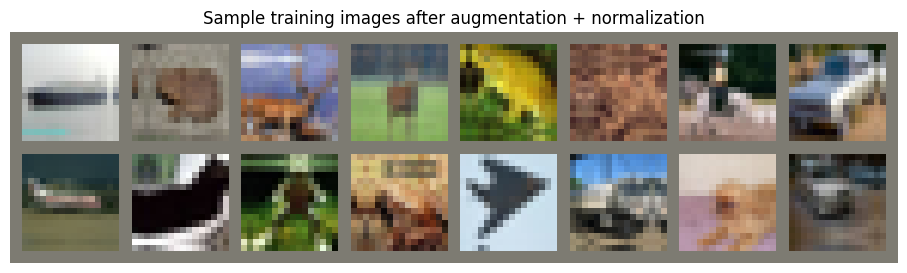

Image batch shape: torch.Size([96, 3, 16, 16])
Label batch shape: torch.Size([96])


In [7]:
def imshow(img):
    """Undo normalization so the grid looks like an image again."""
    mean = torch.tensor(channel_mean).view(3, 1, 1)
    std = torch.tensor(channel_std).view(3, 1, 1)
    img = img * std + mean
    img = torch.clamp(img, 0.0, 1.0)
    npimg = img.numpy()
    plt.figure(figsize=(12, 3))
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')
    plt.title("Sample training images after augmentation + normalization")
    plt.show()


dataiter = iter(trainloader)
images, labels = next(dataiter)
imshow(torchvision.utils.make_grid(images[:16]))
print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)


## 2. Define a ReLU CNN for tiny images

we
- it keeps `16x16` resolution through the first stage and only downsamples twice,
- it uses a wider residual backbone while keeping `ReLU` everywhere,
- it moves more of the regularization burden into `mixup`, weight decay, and EMA,
- it adds optional horizontal-flip test-time augmentation because the training pipeline already teaches flip invariance.

Why this should help:
- preserving spatial detail is important when every pixel carries proportionally more information,
- a wider network can separate similar classes better,
- `mixup + EMA` is often a reliable way to gain the extra few validation points that architecture-only changes miss.


In [8]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, dropout=0.0):
        super().__init__()
        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False,
        )
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu1 = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False,
        )
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu2 = nn.ReLU(inplace=True)
        self.dropout = nn.Dropout2d(dropout) if dropout > 0 else nn.Identity()

        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        identity = self.shortcut(x)
        out = self.relu1(self.bn1(self.conv1(x)))
        out = self.dropout(self.bn2(self.conv2(out)))
        out = self.relu2(out + identity)
        return out


class WideSmallResNet(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()

        # The stem expands channels but keeps the full 16x16 grid so the network
        # can still use fine texture and edge information.
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
        )

        # Stage 1 operates at full resolution.
        self.layer1 = nn.Sequential(
            ResidualBlock(64, 64, stride=1, dropout=0.05),
            ResidualBlock(64, 64, stride=1, dropout=0.05),
            ResidualBlock(64, 64, stride=1, dropout=0.05),
        )

        # Stage 2 shrinks 16x16 -> 8x8 while increasing feature width.
        self.layer2 = nn.Sequential(
            ResidualBlock(64, 128, stride=2, dropout=0.10),
            ResidualBlock(128, 128, stride=1, dropout=0.10),
            ResidualBlock(128, 128, stride=1, dropout=0.10),
        )

        # Stage 3 shrinks 8x8 -> 4x4. Stopping at 4x4 keeps more spatial signal
        # than pushing all the way down to 2x2.
        self.layer3 = nn.Sequential(
            ResidualBlock(128, 256, stride=2, dropout=0.15),
            ResidualBlock(256, 256, stride=1, dropout=0.15),
            ResidualBlock(256, 256, stride=1, dropout=0.15),
        )

        # A final high-capacity stage works at 4x4 without more downsampling.
        self.layer4 = nn.Sequential(
            ResidualBlock(256, 384, stride=1, dropout=0.20),
            ResidualBlock(384, 384, stride=1, dropout=0.20),
        )

        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(384, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.30),
            nn.Linear(256, num_classes),
        )

        self.apply(self._init_weights)

    @staticmethod
    def _init_weights(module):
        if isinstance(module, nn.Conv2d):
            nn.init.kaiming_normal_(module.weight, mode="fan_out", nonlinearity="relu")
        elif isinstance(module, (nn.BatchNorm2d, nn.BatchNorm1d)):
            nn.init.ones_(module.weight)
            nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Linear):
            nn.init.kaiming_normal_(module.weight, nonlinearity="relu")
            if module.bias is not None:
                nn.init.zeros_(module.bias)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x


net = WideSmallResNet(num_classes=NUM_CLASSES)
print(net)


WideSmallResNet(
  (stem): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (layer1): Sequential(
    (0): ResidualBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu1): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu2): ReLU(inplace=True)
      (dropout): Dropout2d(p=0.05, inplace=False)
      (shortcut): Identity()
    )
    (1): ResidualBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=Tru

In [9]:
# Move the model once so every later cell uses the same device placement.
net = net.to(device)
print(f"Model moved to: {device}")


Model moved to: cuda


In [ ]:
# Model Summary 
try:
    from torchinfo import summary

    summary(net, input_size=(1, 3, IMAGE_SIZE, IMAGE_SIZE))
except ImportError:
    total_params = sum(p.numel() for p in net.parameters())
    trainable_params = sum(p.numel() for p in net.parameters() if p.requires_grad)
    print(f"Total parameters    : {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")


Total parameters    : 9,395,018
Trainable parameters: 9,395,018


## 3. Define the loss, optimizer, and learning-rate schedule
We have:
- the wider model giving it more time to converge,
- `mixup` regularizes the classifier without deleting pixels from already tiny images,
- EMA smooths the weight trajectory and often improves validation accuracy even when the raw model is noisy,
- horizontal-flip TTA can recover a little extra accuracy at evaluation time because the training set already includes flips.



In [11]:
TARGET_VAL_ACCURACY = 89.0
EPOCHS = 60
MAX_LR = 1.5e-3
WEIGHT_DECAY = 3e-4
LABEL_SMOOTHING = 0.02
EARLY_STOPPING_PATIENCE = 15
MAX_GRAD_NORM = 1.0
MIXUP_ALPHA = 0.20
MIXUP_PROB = 0.50
EMA_DECAY = 0.995
USE_TTA = True

criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
optimizer = optim.AdamW(net.parameters(), lr=MAX_LR / 15, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=MAX_LR,
    epochs=EPOCHS,
    steps_per_epoch=len(trainloader),
    pct_start=0.15,
    anneal_strategy="cos",
    div_factor=15.0,
    final_div_factor=200.0,
)
scaler = GradScaler(enabled=torch.cuda.is_available())

print(f"Loss                    : CrossEntropyLoss(label_smoothing={LABEL_SMOOTHING})")
print(f"Optimizer               : AdamW(lr={MAX_LR / 15:.2e}, weight_decay={WEIGHT_DECAY})")
print(f"Scheduler               : OneCycleLR(max_lr={MAX_LR}, epochs={EPOCHS})")
print(f"Mixup                   : alpha={MIXUP_ALPHA}, probability={MIXUP_PROB}")
print(f"EMA decay               : {EMA_DECAY}")
print(f"Flip TTA enabled        : {USE_TTA}")
print(f"Target validation score : {TARGET_VAL_ACCURACY:.1f}%")


Loss                    : CrossEntropyLoss(label_smoothing=0.02)
Optimizer               : AdamW(lr=1.00e-04, weight_decay=0.0003)
Scheduler               : OneCycleLR(max_lr=0.0015, epochs=60)
Mixup                   : alpha=0.2, probability=0.5
EMA decay               : 0.995
Flip TTA enabled        : True
Target validation score : 89.0%


/tmp/ipykernel_21638/3288411258.py:25: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=torch.cuda.is_available())


## 4. Train with mixup, EMA, checkpointing, and early stopping

Reasons: 
- `mixup` regularizes the decision boundary without throwing away too much tiny-image detail,
- EMA keeps a smoothed copy of the weights and is often better for validation/test inference than the latest raw step,
- the scheduler still updates every batch,
- the best EMA checkpoint is restored before final evaluation,
- the validation code can use horizontal-flip TTA for a small extra boost.


In [12]:
class ModelEMA:
    def __init__(self, model, decay=0.995):
        self.decay = decay
        self.shadow = copy.deepcopy(model).eval()
        for param in self.shadow.parameters():
            param.requires_grad_(False)

    @torch.no_grad()
    def update(self, model):
        model_state = model.state_dict()
        shadow_state = self.shadow.state_dict()

        for name, shadow_value in shadow_state.items():
            model_value = model_state[name].detach()
            if shadow_value.dtype.is_floating_point:
                shadow_value.mul_(self.decay).add_(model_value, alpha=1.0 - self.decay)
            else:
                shadow_value.copy_(model_value)


def mixup_batch(inputs, labels, alpha=0.2, p=0.5):
    if alpha <= 0 or torch.rand(1).item() >= p:
        return inputs, labels, labels, 1.0, False

    lam = float(np.random.beta(alpha, alpha))
    lam = max(lam, 1.0 - lam)
    index = torch.randperm(inputs.size(0), device=inputs.device)
    mixed_inputs = lam * inputs + (1.0 - lam) * inputs[index]
    labels_b = labels[index]
    return mixed_inputs, labels, labels_b, lam, True


def forward_with_tta(model, inputs, use_tta=False):
    logits = model(inputs)
    if use_tta:
        flipped_inputs = torch.flip(inputs, dims=[3])
        logits = 0.5 * (logits + model(flipped_inputs))
    return logits


def run_train_epoch(model, loader, ema_model):
    model.train()
    running_loss = 0.0
    correct = 0.0
    total = 0

    for inputs, labels in loader:
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        inputs, labels_a, labels_b, lam, _ = mixup_batch(
            inputs,
            labels,
            alpha=MIXUP_ALPHA,
            p=MIXUP_PROB,
        )

        optimizer.zero_grad(set_to_none=True)

        with autocast(enabled=scaler.is_enabled()):
            logits = model(inputs)
            loss = lam * criterion(logits, labels_a) + (1.0 - lam) * criterion(logits, labels_b)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=MAX_GRAD_NORM)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        ema_model.update(model)

        preds = torch.argmax(logits, dim=1)
        batch_correct = lam * (preds == labels_a).sum().item() + (1.0 - lam) * (preds == labels_b).sum().item()

        running_loss += loss.item() * inputs.size(0)
        correct += batch_correct
        total += labels.size(0)

    avg_loss = running_loss / total
    avg_acc = 100.0 * correct / total
    return avg_loss, avg_acc


def evaluate(model, loader, use_tta=False):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with autocast(enabled=scaler.is_enabled()):
                logits = forward_with_tta(model, inputs, use_tta=use_tta)
                loss = criterion(logits, labels)

            preds = torch.argmax(logits, dim=1)
            running_loss += loss.item() * inputs.size(0)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            all_preds.extend(preds.cpu().numpy().tolist())
            all_labels.extend(labels.cpu().numpy().tolist())

    avg_loss = running_loss / total
    avg_acc = 100.0 * correct / total
    return avg_loss, avg_acc, np.array(all_preds), np.array(all_labels)


ema_model = ModelEMA(net, decay=EMA_DECAY)
best_val_acc = 0.0
best_epoch = 0
epochs_without_improvement = 0
best_state = None

train_loss_hist = []
train_acc_hist = []
val_loss_hist = []
val_acc_hist = []
lr_hist = []

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_train_epoch(net, trainloader, ema_model)
    val_loss, val_acc, _, _ = evaluate(ema_model.shadow, valloader, use_tta=USE_TTA)
    current_lr = optimizer.param_groups[0]["lr"]

    train_loss_hist.append(train_loss)
    train_acc_hist.append(train_acc)
    val_loss_hist.append(val_loss)
    val_acc_hist.append(val_acc)
    lr_hist.append(current_lr)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch
        epochs_without_improvement = 0
        best_state = {k: v.detach().cpu().clone() for k, v in ema_model.shadow.state_dict().items()}
    else:
        epochs_without_improvement += 1

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.2f}% | "
        f"LR: {current_lr:.2e}"
    )

    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print(
            f"Early stopping triggered after {epoch} epochs "
            f"without validation improvement."
        )
        break

if best_state is not None:
    net.load_state_dict(best_state)
    net.to(device)

print(f"\nBest validation accuracy: {best_val_acc:.2f}% at epoch {best_epoch}")
if best_val_acc >= TARGET_VAL_ACCURACY:
    print("Target reached: validation accuracy is at or above 89%.")
else:
    print(
        "Target not reached in this run. This version is more competitive, but the final "
        "score still depends on the actual data split, runtime, and hardware."
    )


/tmp/ipykernel_21638/3788536484.py:59: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=scaler.is_enabled()):
/tmp/ipykernel_21638/3788536484.py:68: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()
/tmp/ipykernel_21638/3788536484.py:96: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=scaler.is_enabled()):


Epoch 01/60 | Train Loss: 2.1042 | Train Acc: 25.96% | Val Loss: 2.1286 | Val Acc: 22.58% | LR: 1.42e-04
Epoch 02/60 | Train Loss: 1.7619 | Train Acc: 38.28% | Val Loss: 1.5785 | Val Acc: 44.46% | LR: 2.64e-04
Epoch 03/60 | Train Loss: 1.6178 | Train Acc: 44.87% | Val Loss: 1.2795 | Val Acc: 56.43% | LR: 4.50e-04
Epoch 04/60 | Train Loss: 1.4951 | Train Acc: 50.05% | Val Loss: 1.1036 | Val Acc: 64.17% | LR: 6.79e-04
Epoch 05/60 | Train Loss: 1.3847 | Train Acc: 54.71% | Val Loss: 0.9830 | Val Acc: 68.85% | LR: 9.22e-04
Epoch 06/60 | Train Loss: 1.2902 | Train Acc: 58.55% | Val Loss: 0.8937 | Val Acc: 72.12% | LR: 1.15e-03
Epoch 07/60 | Train Loss: 1.2204 | Train Acc: 61.38% | Val Loss: 0.8232 | Val Acc: 74.78% | LR: 1.34e-03
Epoch 08/60 | Train Loss: 1.2068 | Train Acc: 62.71% | Val Loss: 0.7747 | Val Acc: 76.27% | LR: 1.46e-03
Epoch 09/60 | Train Loss: 1.1177 | Train Acc: 65.64% | Val Loss: 0.7264 | Val Acc: 77.92% | LR: 1.50e-03
Epoch 10/60 | Train Loss: 1.0420 | Train Acc: 68.51% | 

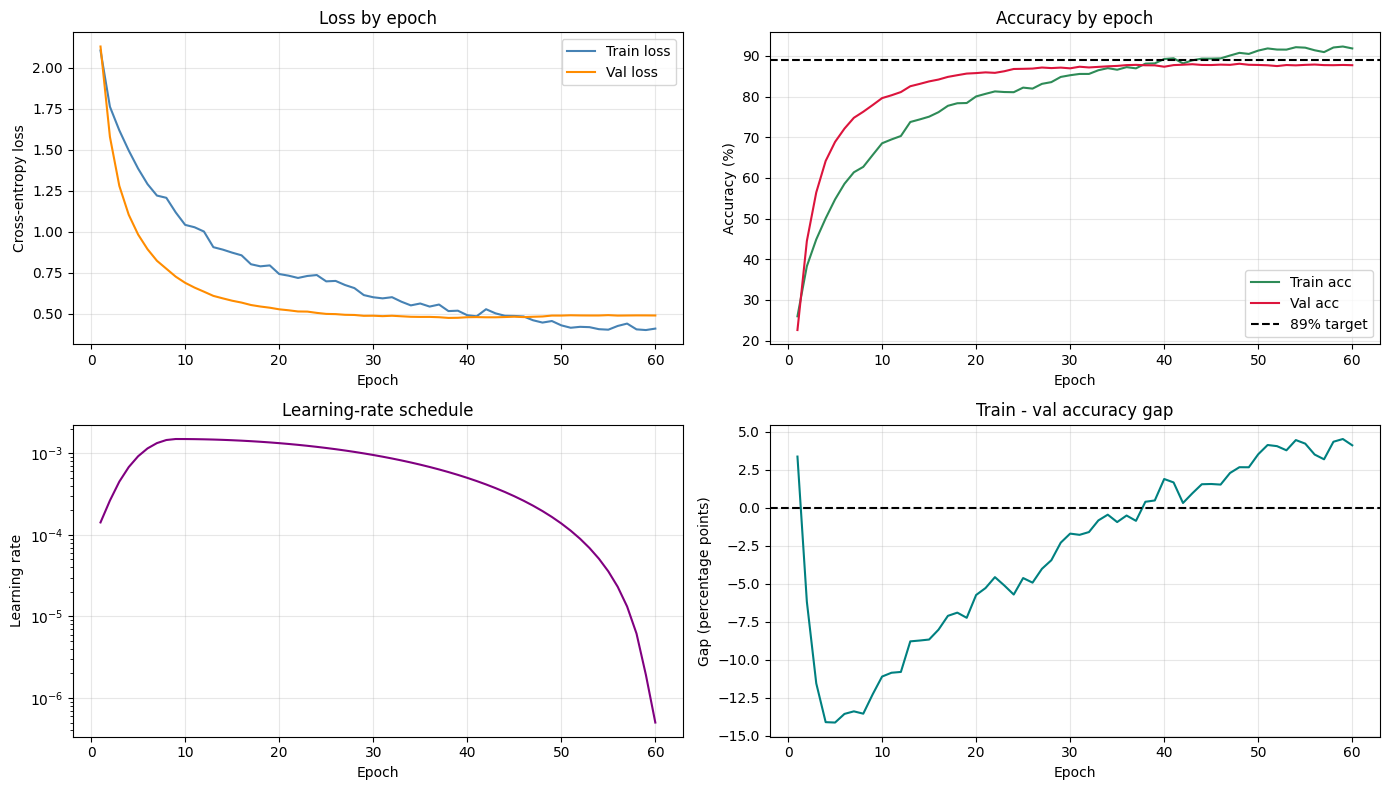

In [13]:
# These plots help explain how the stronger single-model recipe behaved.
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
epochs_ran = range(1, len(train_loss_hist) + 1)

axes[0, 0].plot(epochs_ran, train_loss_hist, color='steelblue', label='Train loss')
axes[0, 0].plot(epochs_ran, val_loss_hist, color='darkorange', label='Val loss')
axes[0, 0].set_title('Loss by epoch')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Cross-entropy loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(epochs_ran, train_acc_hist, color='seagreen', label='Train acc')
axes[0, 1].plot(epochs_ran, val_acc_hist, color='crimson', label='Val acc')
axes[0, 1].axhline(y=TARGET_VAL_ACCURACY, color='black', linestyle='--', label='89% target')
axes[0, 1].set_title('Accuracy by epoch')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy (%)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(epochs_ran, lr_hist, color='purple')
axes[1, 0].set_title('Learning-rate schedule')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Learning rate')
axes[1, 0].set_yscale('log')
axes[1, 0].grid(True, alpha=0.3)

generalization_gap = np.array(train_acc_hist) - np.array(val_acc_hist)
axes[1, 1].plot(epochs_ran, generalization_gap, color='teal')
axes[1, 1].axhline(y=0.0, color='black', linestyle='--')
axes[1, 1].set_title('Train - val accuracy gap')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Gap (percentage points)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 5. Evaluate on the held-out validation set

Why?
- the best EMA checkpoint is chosen using validation accuracy, so we re-evaluate after restoring it,
- per-class accuracy helps explain where the model is still weak even if the overall score is strong,



In [14]:
val_loss, overall_acc, all_preds, all_labels = evaluate(net, valloader, use_tta=USE_TTA)
print(f"Validation loss: {val_loss:.4f}")
print(f"Overall validation accuracy: {overall_acc:.2f}%")
print(f"Evaluation recipe: EMA checkpoint + flip TTA = {USE_TTA}")

print("\nPer-class accuracy:")
for cls in range(NUM_CLASSES):
    mask = all_labels == cls
    cls_count = int(mask.sum())
    cls_acc = 100.0 * np.mean(all_preds[mask] == all_labels[mask]) if cls_count > 0 else 0.0
    print(f"  Class {cls}: {cls_acc:6.2f}% ({cls_count} samples)")


/tmp/ipykernel_21638/3788536484.py:96: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=scaler.is_enabled()):


Validation loss: 0.4838
Overall validation accuracy: 88.08%
Evaluation recipe: EMA checkpoint + flip TTA = True

Per-class accuracy:
  Class 0:  90.98% (510 samples)
  Class 1:  91.04% (502 samples)
  Class 2:  84.98% (506 samples)
  Class 3:  75.00% (504 samples)
  Class 4:  85.60% (500 samples)
  Class 5:  82.57% (505 samples)
  Class 6:  91.34% (508 samples)
  Class 7:  90.66% (503 samples)
  Class 8:  95.04% (504 samples)
  Class 9:  93.57% (498 samples)


## 6. Evaluate on the full training set without augmentation

Reasons: 
- a much higher training score than validation score usually means overfitting,
- evaluating without augmentation gives a cleaner apples-to-apples comparison with validation,
- the train-vs-validation gap helps decide whether to add more regularization or more capacity.


In [15]:
full_train_eval = ImageDataset(X_train, y_train, mean=channel_mean, std=channel_std, augment=False)
full_train_loader = DataLoader(
    full_train_eval,
    batch_size=256,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

train_eval_loss, train_acc, _, _ = evaluate(net, full_train_loader, use_tta=False)
print(f"Training loss without augmentation: {train_eval_loss:.4f}")
print(f"Training accuracy of the network : {train_acc:.2f}%")
print(f"Gap to validation accuracy       : {train_acc - overall_acc:.2f} percentage points")


/tmp/ipykernel_21638/3788536484.py:96: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=scaler.is_enabled()):


Training loss without augmentation: 0.2174
Training accuracy of the network : 97.35%
Gap to validation accuracy       : 9.27 percentage points


## 7. Generate test predictions for submission

Why this step is last:
- we restore the best EMA checkpoint before inference,
- we optionally use flip TTA because the training pipeline already learned horizontal-flip invariance,
- the exported CSV therefore reflects the strongest single-model validation-time recipe from the notebook.


In [16]:
def predict_loader(model, loader, use_tta=False):
    model.eval()
    output_labels = []

    with torch.no_grad():
        for images, _ in loader:
            images = images.to(device, non_blocking=True)
            with autocast(enabled=scaler.is_enabled()):
                logits = forward_with_tta(model, images, use_tta=use_tta)
            preds = torch.argmax(logits, dim=1)
            output_labels.extend(preds.cpu().numpy().tolist())

    return output_labels


output_labels = predict_loader(net, testloader, use_tta=USE_TTA)
print(f"Generated {len(output_labels)} test predictions.")
print(f"Unique predicted classes: {sorted(set(output_labels))}")
print(f"Flip TTA used for inference: {USE_TTA}")


/tmp/ipykernel_21638/3017793195.py:8: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=scaler.is_enabled()):


Generated 18000 test predictions.
Unique predicted classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Flip TTA used for inference: True


In [17]:
test_predictions = pd.DataFrame({
    'rowId': np.arange(len(output_labels), dtype=np.int64),
    'label': np.array(output_labels, dtype=np.int64),
})

output_csv = base_path / 'my_cnn_results_improved_v2.csv'
test_predictions.to_csv(output_csv, index=False)

print(test_predictions.head())
print(f"\nPredictions saved to: {output_csv}")


   rowId  label
0      0      6
1      1      9
2      2      8
3      3      8
4      4      4

Predictions saved to: /content/drive/MyDrive/image-classification-challenge-w-26/W2026-0-0.3/my_cnn_results_improved_v2.csv


## 8. Save and reload the trained model

Why save only `state_dict()`:
- it is the standard PyTorch format,
- it keeps the file smaller,
- it avoids pickling the full Python object graph,
- it makes reloading explicit and reproducible.


In [18]:
model_path = Path.cwd() / 'my_cnn_model_improved_v2.pth'
torch.save(net.state_dict(), model_path)
print(f"Model saved to {model_path}")


Model saved to /content/my_cnn_model_improved_v2.pth


In [ ]:
# When restoring the model later, recreate the architecture first and then
# load the saved weights.
#
# reloaded_net = WideSmallResNet(num_classes=NUM_CLASSES)
# reloaded_net.load_state_dict(torch.load(model_path, map_location=device))
# reloaded_net.to(device)
# reloaded_net.eval()
# print("Model reloaded and ready for inference.")
